# Covid analysis - machine learning

#### Import bibliotek

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, \
precision_recall_curve, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from datetime import timedelta
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

import pickle

In [2]:
df = pd.read_csv('data/covid-data-cleaned.csv')

Format csv jest plikiem tekstowym, stąd nie przechowuje informacji o typach danych. Po odczytaniu pliku z oczyszczonymi danymi csv należy ponownie zmienić format daty.

In [3]:
df['date'] = pd.to_datetime(df['date'])

### Predykcja wzrostu liczby zgonów o ponad 20% w ciągu 3 dni

Dane zostały wzbogacone o cechy czasowe, takie jak 7-dniowe średnie kroczące, opóźnienia oraz różnice, które opisują krótkoterminowe zmiany liczby przypadków i zgonów. Na ich podstawie zdefiniowano zmienną celu określającą, czy liczba zgonów wzrośnie o więcej niż 20% w ciągu kolejnych 3 dni względem dnia bieżącego.

Do klasyfikacji wykorzystano model Random Forest, z zastosowaniem:

- oversamplingu w celu zrównoważenia klas
- rozszerzonego zakresu hiperparametrów
- progu decyzyjnego (0.6) dobranego w celu zbalansowania czułości i precyzji

In [4]:
df = df.sort_values(['location', 'date'])

df['new_cases_7d_avg'] = df.groupby('location')['new_cases'].transform(lambda x: x.rolling(7).mean())
df['new_deaths_7d_avg'] = df.groupby('location')['new_deaths'].transform(lambda x: x.rolling(7).mean())
df['new_cases_lag_3'] = df.groupby('location')['new_cases'].shift(3)
df['new_deaths_lag_3'] = df.groupby('location')['new_deaths'].shift(3)
df['cases_diff'] = df.groupby('location')['new_cases'].diff()
df['deaths_diff'] = df.groupby('location')['new_deaths'].diff()

f1 = df.groupby('location')['new_deaths'].shift(-1)
f2 = df.groupby('location')['new_deaths'].shift(-2)
f3 = df.groupby('location')['new_deaths'].shift(-3)

max_future_deaths = pd.concat([f1, f2, f3], axis=1).max(axis=1)

df['target'] = ((max_future_deaths > df['new_deaths'] * 1.2) & (max_future_deaths > 5)).astype(int)

features = [
    'new_cases', 'new_cases_smoothed', 'new_deaths',
    'stringency_index', 'reproduction_rate', 'positive_rate', 'tests_per_case',
    'new_vaccinations_smoothed', 'population_density',
    'gdp_per_capita', 'hospital_beds_per_thousand',
    'life_expectancy', 'human_development_index',
    'new_cases_7d_avg', 'new_deaths_7d_avg',
    'new_cases_lag_3', 'new_deaths_lag_3',
    'cases_diff', 'deaths_diff'
]

df_model = df.dropna(subset=features + ['target'])
X = df_model[features]
y = df_model['target']

split_date = df['date'].max() - pd.Timedelta(days=120)

train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

X_train = train[features]
y_train = train['target']
X_test = test[features]
y_test = test['target']

ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)


#### Random Forest Classifier

In [5]:
%%time

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_bal, y_train_bal)

y_proba = model.predict_proba(X_test)[:, 1]
threshold = 0.6
y_pred_custom = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_pred_custom, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0      0.996     0.990     0.993     25506
           1      0.616     0.820     0.703       522

    accuracy                          0.986     26028
   macro avg      0.806     0.905     0.848     26028
weighted avg      0.989     0.986     0.987     26028

Confusion matrix:
[[25239   267]
 [   94   428]]
CPU times: total: 7min 49s
Wall time: 1min 25s


Recall: dla klasy 0 wynosi 0.990, co oznacza, że model poprawnie identyfikuje większość przypadków bez istotnego wzrostu liczby zgonów. Dla klasy 1 recall osiąga wartość 0.820, wskazując na skuteczne wykrywanie większości faktycznych wzrostów.

Precision: dla klasy 0 jest bardzo wysokie (0.996), co oznacza, że prawie wszystkie przewidywania tej klasy są trafne. W przypadku klasy 1 precision wynosi 0.616, co wskazuje, że ponad 60% sygnałów wzrostu zgonów jest poprawnych.

F1-score: dla klasy 0 osiąga wartość 0.993, potwierdzając bardzo dobrą jakość klasyfikacji tej klasy. Dla klasy 1 f1-score wynosi 0.703, co wskazuje na dobry kompromis pomiędzy precision i recall.

Accuracy modelu wynosi 98.6%.

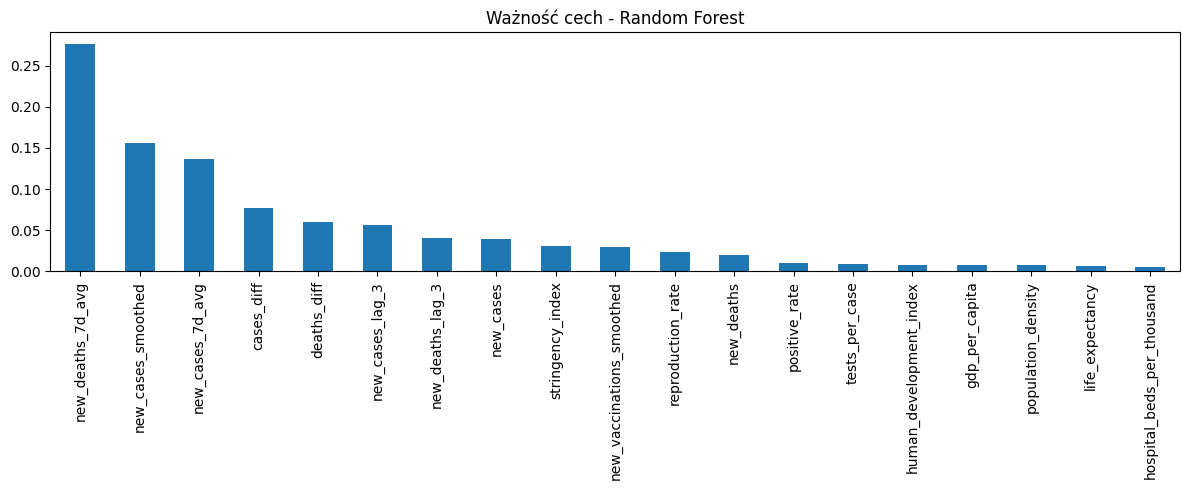

In [6]:
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).plot.bar(figsize=(12, 5))
plt.title("Ważność cech - Random Forest")
plt.tight_layout()
plt.show()

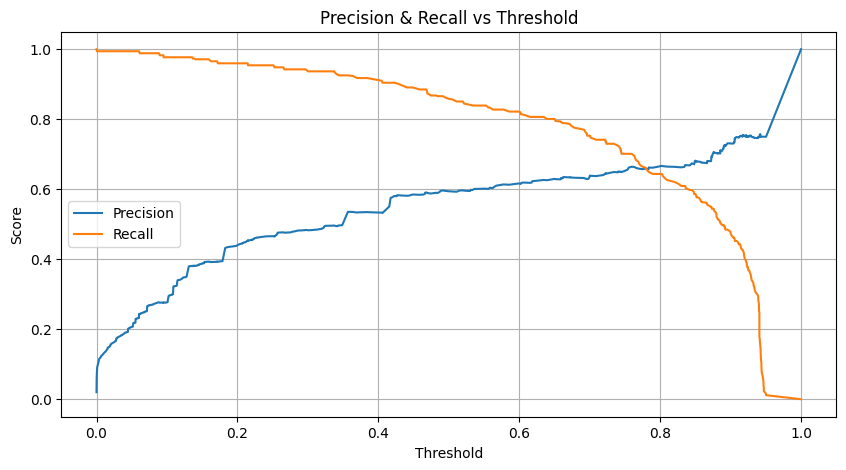

In [7]:
y_proba = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

thresholds = np.append(thresholds, 1.0)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision, label='Precision')
plt.plot(thresholds, recall, label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

#### XGBOOST

In [8]:
%%time

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_bal, y_train_bal)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.6
y_pred_xgb = (y_proba_xgb > threshold).astype(int)

print(classification_report(y_test, y_pred_xgb, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0      0.999     0.986     0.992     25506
           1      0.574     0.931     0.710       522

    accuracy                          0.985     26028
   macro avg      0.786     0.958     0.851     26028
weighted avg      0.990     0.985     0.987     26028

Confusion matrix:
[[25145   361]
 [   36   486]]
CPU times: total: 39.9 s
Wall time: 7.45 s


Recall: model utrzymuje bardzo wysoką skuteczność dla klasy 0 (0.986), poprawnie rozpoznając niemal wszystkie przypadki bez istotnego wzrostu liczby zgonów. Dla klasy 1 recall wynosi 0.931, co oznacza bardzo wysoką wykrywalność faktycznych wzrostów.

Precision: przewidywania klasy 0 są prawie w całości trafne (0.999). Dla klasy 1 precision na poziomie 0.574 wskazuje, że lekko ponad połowa wygenerowanych sygnałów wzrostu jest poprawna.

F1-score: dla klasy 0 wynosi 0.992 i potwierdza bardzo dobrą jakość klasyfikacji. W przypadku klasy 1 f1-score = 0.710 pokazuje zrównoważone połączenie wysokiego recall z umiarkowaną precision.

Accuracy osiąga wartość 98.5%.

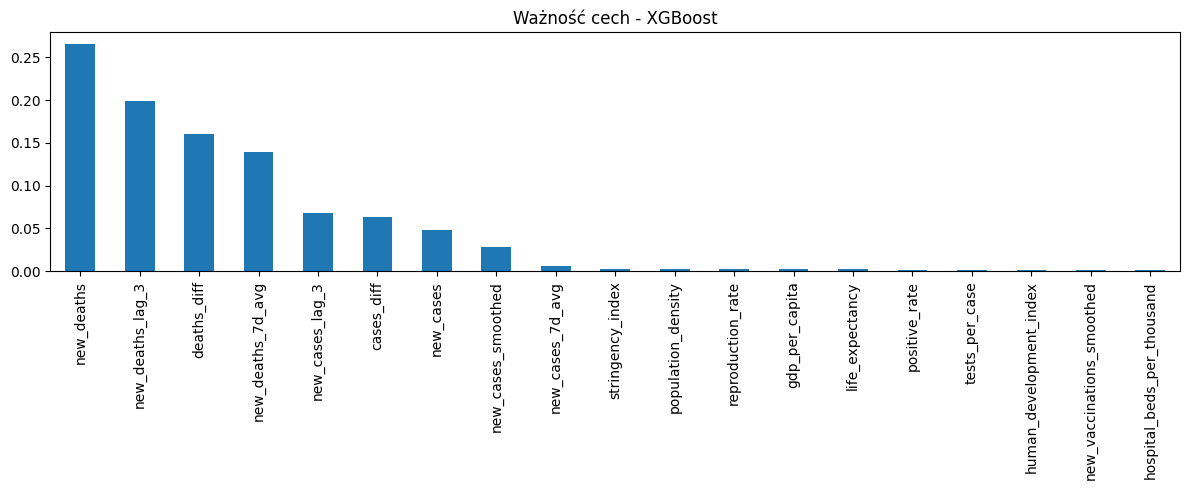

In [9]:
feature_importance_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importance_xgb.sort_values(ascending=False).plot.bar(figsize=(12, 5))
plt.title("Ważność cech - XGBoost")
plt.tight_layout()
plt.show()

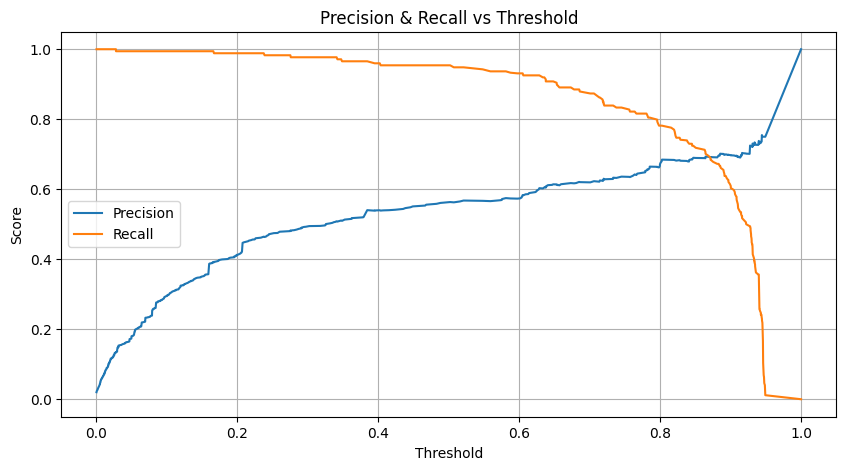

In [10]:
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)

thresholds_xgb = np.append(thresholds_xgb, 1.0)

plt.figure(figsize=(10, 5))
plt.plot(thresholds_xgb, precision_xgb, label='Precision')
plt.plot(thresholds_xgb, recall_xgb, label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

#### Porównanie modeli z GridSearchCV

In [11]:
def run_model_gs(model, param_grid, X_train, y_train, X_test, y_test, threshold=0.5):
    """
    - model: RandomForestClassifier, XGBClassifier, itd.
    - param_grid w formacie {'param': [wartosci]}
    - dane X, y
    - threshold dla predict_proba
    """

    sampler = RandomOverSampler(random_state=42)
    X_train_bal, y_train_bal = sampler.fit_resample(X_train, y_train)

    grid = GridSearchCV(model, param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1)
    grid.fit(X_train_bal, y_train_bal)

    print(f"\nNajlepsze parametry: {grid.best_params_}\n")
    best_model = grid.best_estimator_

    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return best_model


#### Random Forest Classifier

In [12]:
%%time

rf_model_gs = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2', None]
}

best_rf = run_model_gs(model=rf_model_gs, 
                       param_grid=rf_params, 
                       X_train=X_train, 
                       y_train=y_train, 
                       X_test=X_test, 
                       y_test=y_test,
                       threshold=0.6
                      )

Fitting 3 folds for each of 72 candidates, totalling 216 fits

Najlepsze parametry: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}

Classification Report:
              precision    recall  f1-score   support

           0      0.998     0.988     0.993     25506
           1      0.601     0.902     0.721       522

    accuracy                          0.986     26028
   macro avg      0.799     0.945     0.857     26028
weighted avg      0.990     0.986     0.987     26028

Confusion Matrix:
[[25193   313]
 [   51   471]]
CPU times: total: 1min 6s
Wall time: 47min 47s


Recall: po strojeniu hiperparametrów model poprawnie klasyfikuje większość obserwacji klasy 0 (0.988). Dla klasy 1 recall wzrasta do 0.902, co wskazuje na bardzo dobrą zdolność wykrywania istotnych wzrostów liczby zgonów.

Precision: dla klasy 0 pozostaje bardzo wysoka (0.998). Precision klasy 1 wynosi 0.601, co oznacza, że około 60% przewidywanych wzrostów jest zgodnych z rzeczywistością.

F1-score: jakość klasyfikacji klasy 0 utrzymuje się na bardzo wysokim poziomie (0.993). Dla klasy 1 f1-score = 0.721, co stanowi najlepszy wynik spośród analizowanych modeli.

Accuracy modelu wynosi 98.6%.

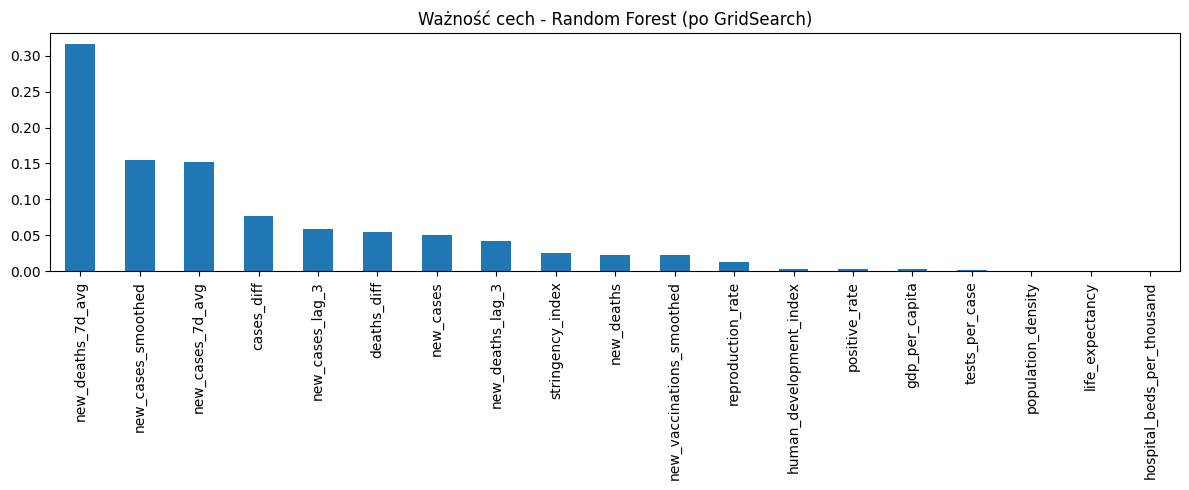

In [13]:
feature_importance_rf_gs = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feature_importance_rf_gs.sort_values(ascending=False).plot.bar(figsize=(12, 5))
plt.title("Ważność cech - Random Forest (po GridSearch)")
plt.tight_layout()
plt.show()

#### XGBOOST

In [14]:
%%time

xgb_model_gs = XGBClassifier(eval_metric='logloss', random_state=42)

xgb_params = {
    'n_estimators': [100, 300],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.5, 1.0], 
    'colsample_bytree': [0.5, 1.0],
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 3]
}

best_xgb = run_model_gs(model=xgb_model_gs, 
                        param_grid=xgb_params, 
                        X_train=X_train, 
                        y_train=y_train, 
                        X_test=X_test, 
                        y_test=y_test,
                        threshold=0.6)

Fitting 3 folds for each of 288 candidates, totalling 864 fits

Najlepsze parametry: {'colsample_bytree': 1.0, 'gamma': 3, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 10, 'n_estimators': 300, 'subsample': 0.5}

Classification Report:
              precision    recall  f1-score   support

           0      0.998     0.987     0.992     25506
           1      0.586     0.902     0.710       522

    accuracy                          0.985     26028
   macro avg      0.792     0.945     0.851     26028
weighted avg      0.990     0.985     0.987     26028

Confusion Matrix:
[[25173   333]
 [   51   471]]
CPU times: total: 53 s
Wall time: 27min 42s


Recall: model zachowuje wysoką skuteczność dla klasy 0 (0.987). Dla klasy 1 recall wynosi 0.902, co oznacza, że zdecydowana większość faktycznych wzrostów została poprawnie wykryta.

Precision: trafność przewidywań klasy 0 jest bardzo wysoka (0.998). Precision dla klasy 1 na poziomie 0.586 wskazuje na umiarkowaną liczbę fałszywych sygnałów.

F1-score: dla klasy 0 osiąga wartość 0.992, potwierdzając stabilną jakość klasyfikacji. W przypadku klasy 1 f1-score = 0.710, co wskazuje na dobry kompromis pomiędzy wykrywalnością a precyzją.

Accuracy modelu wynosi 98.5%.

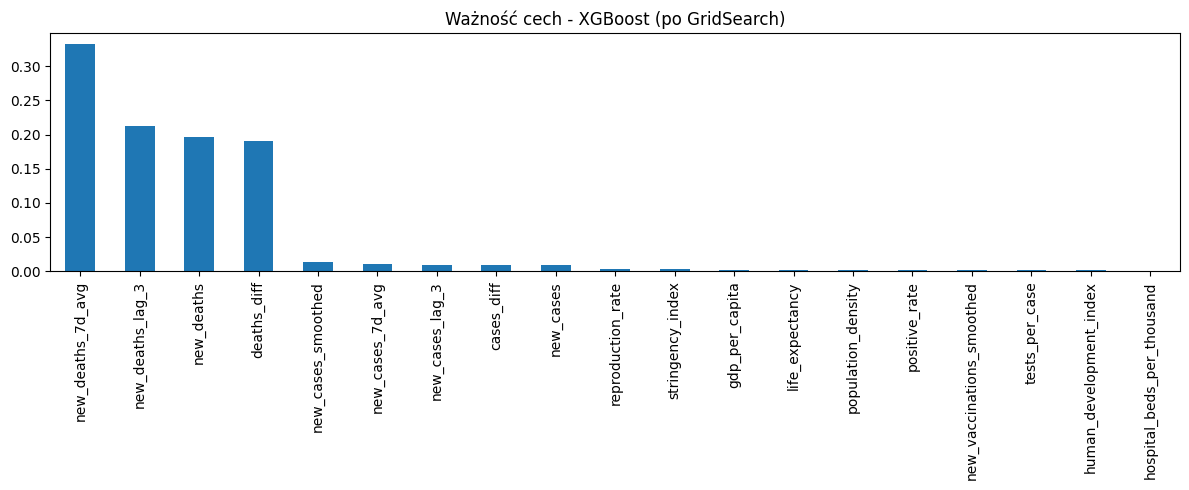

In [15]:
feature_importance_xgb_gs = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
feature_importance_xgb_gs.sort_values(ascending=False).plot.bar(figsize=(12, 5))
plt.title("Ważność cech - XGBoost (po GridSearch)")
plt.tight_layout()
plt.show()

### Wyniki GridSearch

Przeprowadzono przeszukiwanie parametrów poprzez GridSearchCV dla obu modeli: Random Forest oraz XGBoost, z uwzględnieniem opcji oversamplingu danych.

Najlepsze zestawy parametrów:
- Random Forest:
  - max_depth = 7
  - max_features = 'sqrt'
  - min_samples_leaf = 2
  - min_samples_split = 2
  - n_estimators = 150
- XGBoost:
  - max_depth = 6
  - n_estimators = 300
  - learning_rate = 0.01
  - gamma = 3
  - colsample_bytree = 1.0
  - subsample = 0.5
  - min_child_weight = 10


Porównano modele Random Forest oraz XGBoost w wersji bazowej oraz po strojenia hiperparametrów z użyciem GridSearch.

Modele bazowe osiągnęły zbliżoną skuteczność ogólną (accuracy ~ 98.5–98.6%). W obu przypadkach model bardzo dobrze klasyfikuje klasę 0. Dla klasy 1 XGBoost uzyskał wyższy recall (0.931) niż Random Forest (0.820), natomiast Random Forest charakteryzował się wyższą precision (0.616 vs 0.574). Wartości f1-score dla klasy 1 były zbliżone (0.703–0.710).

Po zastosowaniu Grid Search oba modele poprawiły wykrywalność klasy 1. Random Forest osiągnął recall = 0.902 oraz f1-score = 0.721, natomiast XGBoost uzyskał recall = 0.902 oraz f1-score = 0.710. Precision dla klasy 1 była nieco wyższa w przypadku Random Forest (0.601 vs 0.586).

Najlepsze wyniki uzyskał model Random Forest po Grid Search, osiągając najwyższy f1-score dla klasy 1 przy zachowaniu bardzo wysokiej accuracy (98.6%).

Pod względem kosztu obliczeniowego proces strojenia XGBoost był szybszy - Grid Search dla tego modelu trwał około 28 minut, podczas gdy dla Random Forest około 48 minut.

#### Zapisanie modelu

Biorąc pod uwagę przyjęte założenie - zmniejszenie liczby niewykrytych rzeczywistych wzrostów liczby zgonów - zoptymalizowany przez mechanizm GridSearch model Random Forest jest najlepszym modelem. 

In [18]:
with open('best_rf.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model zapisany do 'best_rf.pkl'")

Model zapisany do 'best_rf.pkl'


In [17]:
# with open('best_rf.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)